# CRN-SVM Parallel Batch


## Setup
This block imports the numerical and plotting packages used throughout the notebook.


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
from scipy.integrate import solve_ivp
import os


## CRN Engine
This block defines the reaction data model and the compiled mass-action evaluator used by both the oscillator and the SVM network.


In [2]:
@dataclass(frozen=True)
class Reaction:
    """Single mass-action reaction entry.

    Parameters
    ----------
    reactants : Dict[str, int]
        Reactant stoichiometry (species -> exponent/order).
    products : Dict[str, int]
        Product stoichiometry (species -> count).
    k : float
        Reaction rate constant.
    oscillator : Optional[int]
        Oscillator channel index. When this is ``None``, the compiled CRN stores
        the sentinel value ``-1`` to denote an always-on reaction. During RHS
        evaluation, only nonnegative oscillator indices scale the reaction rate by
        the corresponding entry of the oscillator vector.
    """
    reactants: Dict[str, int]
    products: Dict[str, int]
    k: float
    oscillator: Optional[int] = None


class MassActionCRN:
    """Compiled mass-action CRN with optional oscillator-indexed reactions.

    The compiler stores stoichiometric deltas and reactant lookup tables once so
    repeated RHS evaluations during ODE integration only assemble reaction fluxes
    and multiply them by the precomputed stoichiometric matrix.
    """

    def __init__(self, species: List[str], reactions: List[Reaction]):
        """Initialize and compile CRN structure for fast RHS evaluation."""
        self.species = list(species)
        self.reactions = list(reactions)
        self.s_index = {s: i for i, s in enumerate(self.species)}
        self._compile()

    def _compile(self):
        """Compile stoichiometry and reactant lookup arrays used in rhs()."""
        m = len(self.species)
        r = len(self.reactions)
        self._delta = np.zeros((r, m), dtype=float)
        self._ks = np.zeros(r, dtype=float)
        # `-1` is the sentinel for reactions that are not tied to any oscillator
        # channel. Those reactions remain active regardless of the current
        # oscillator state and therefore bypass oscillator-based rate scaling.
        # In this notebook, that case is used by the Hopf clock subnetwork, which
        # must evolve continuously while driving the oscillator-indexed SVM reactions.
        self._oscillators = np.full(r, -1, dtype=int)
        self._react_idx = []
        self._react_pow = []

        for j, rxn in enumerate(self.reactions):
            # Store scalar rate constant for reaction j.
            self._ks[j] = float(rxn.k)
            # Reactions with an explicit oscillator index are scaled later by the
            # corresponding oscillator channel. Reactions left at `-1` are always
            # on and are unaffected by the oscillator vector.
            if rxn.oscillator is not None:
                self._oscillators[j] = int(rxn.oscillator)
            # Stoichiometric net change vector for reaction j.
            for sp, nu in rxn.reactants.items():
                self._delta[j, self.s_index[sp]] -= float(nu)
            for sp, nu in rxn.products.items():
                self._delta[j, self.s_index[sp]] += float(nu)

            # Precompute reactant indices/powers for fast mass-action monomial evaluation.
            idxs, pows = [], []
            for sp, nu in rxn.reactants.items():
                idxs.append(self.s_index[sp])
                pows.append(int(nu))
            self._react_idx.append(np.array(idxs, dtype=int))
            self._react_pow.append(np.array(pows, dtype=int))

    def rhs(self, y: np.ndarray, oscillator_vec: np.ndarray):
        """Return species derivatives and reaction fluxes for state ``y``.

        Each reaction flux is the mass-action monomial associated with its
        reactants, scaled by the reaction constant and, when present, by the
        currently active oscillator weight.
        """
        r = len(self.reactions)
        v = np.zeros(r, dtype=float)

        for j in range(r):
            rate = self._ks[j]
            g = self._oscillators[j]
            # Only reactions assigned to a nonnegative oscillator channel are
            # modulated by the current oscillator vector. In this notebook, the
            # Hopf-clock reactions are the always-on exception, whereas the SVM
            # reactions are tied to specific oscillator channels.
            if g >= 0:
                # A one-hot oscillator vector leaves the selected channel at full
                # strength and suppresses the others to zero for that phase.
                rate *= float(oscillator_vec[g])

            idxs = self._react_idx[j]
            pows = self._react_pow[j]
            if idxs.size == 0:
                v[j] = rate
            else:
                term = 1.0
                for ii, nu in zip(idxs, pows):
                    term *= y[ii] ** nu
                v[j] = rate * term

        dy = v @ self._delta
        return dy, v


## Hopf Clock And Oscillator Readout (Implementing Oscillator Module)
This section defines the oscillator-driven scheduler used in the notebook. The clock is encoded in dual rail by the nonnegative species `H_Xp, H_Xn, H_Zp, H_Zn`, which are decoded into signed coordinates `x = H_Xp - H_Xn` and `z = H_Zp - H_Zn`.

The decoded dynamics follow the Hopf normal form
- `x_dot = (mu - x^2 - z^2) x - omega z`
- `z_dot = (mu - x^2 - z^2) z + omega x`

For `mu > 0`, the decoded state converges to a limit cycle. The phase `theta = atan2(z, x) mod 2*pi` is discretized into `n_clock` bins, yielding a one-hot oscillator vector with exact peak value `1.0` for the active oscillator.


In [3]:
@dataclass(frozen=True)
class HopfClockParams:
    """Parameters controlling the dual-rail Hopf clock.

    Attributes
    ----------
    n_clock : int
        Number of oscillator channels in one full control cycle.
    mu : float
        Radial growth parameter of the Hopf normal form. The stable orbit has
        radius approximately ``sqrt(mu)`` when ``mu > 0``.
    omega : float
        Angular frequency in radians per unit time.
    kappa : float
        Compatibility parameter retained in the notebook configuration interface.
    eps : float
        Small numerical guard used when initializing or decoding the clock state.
    """
    n_clock: int = 12
    mu: float = 1.0
    omega: float = 2*np.pi/114.0
    kappa: float = 25.0
    eps: float = 1e-15


def hopf_make_params(n_clock: int, phase_duration: float, mu: float = 1.0, kappa: float = 25.0):
    """Construct Hopf-clock parameters from the requested oscillator timing.

    The oscillator period is matched to ``n_clock * phase_duration`` so one full
    orbit corresponds to one traversal of the oscillator schedule.
    """
    period = float(n_clock) * float(phase_duration)
    return HopfClockParams(n_clock=n_clock, mu=mu, omega=2*np.pi/period, kappa=kappa)


def hopf_phase(y: np.ndarray):
    """Return the wrapped oscillator phase in ``[0, 2*pi)`` for decoded state ``[x, z]``."""
    th = np.arctan2(float(y[1]), float(y[0]))
    return th + 2*np.pi if th < 0 else th


def decode_clock_dualrail(y_clock_dr: np.ndarray):
    """Decode the dual-rail clock species into the signed state ``[x, z]``."""
    x = float(y_clock_dr[0] - y_clock_dr[1])
    z = float(y_clock_dr[2] - y_clock_dr[3])
    return np.array([x, z], dtype=float)


def init_clock_dualrail_phase0(params: HopfClockParams, eps: float = 1e-9):
    """Initialize the dual-rail Hopf species near phase zero on the limit cycle.

    A small offset is placed on the opposite rails so the initial state is not
    exactly singular in either rail pair.
    """
    r = float(np.sqrt(max(params.mu, 1e-12)))
    return np.array([r, eps, eps, eps], dtype=float)


def build_dualrail_hopf_clock_crn(params: HopfClockParams, k_ann: float = 80.0, rate_scale: float = 1.0):
    """Build the dual-rail mass-action Hopf oscillator subnetwork.

    Decoded state representation
    ----------------------------
    x = H_Xp - H_Xn,    z = H_Zp - H_Zn.

    Target Hopf dynamics
    --------------------
    x' = (mu - x^2 - z^2)x - omega z
    z' = (mu - x^2 - z^2)z + omega x

    Equivalent polynomial form used for reaction compilation
    --------------------------------------------------------
    x' = mu*x - x^3 - x*z^2 - omega*z
    z' = mu*z - z^3 - z*x^2 + omega*x

    Reaction-network form (mass-action motifs)
    ------------------------------------------
    For each signed monomial term c*x^a*z^b:
    1) Expand x=(H_Xp-H_Xn), z=(H_Zp-H_Zn) by binomial identities.
    2) For each expanded nonzero term, create a catalytic production reaction:
         reactants -> reactants + H_Xp   (if contribution to x' is positive)
         reactants -> reactants + H_Xn   (if contribution to x' is negative)
         reactants -> reactants + H_Zp   (if contribution to z' is positive)
         reactants -> reactants + H_Zn   (if contribution to z' is negative)
       with rate |c_term|.
    3) Add rail-annihilation stabilization:
         H_Xp + H_Xn -> ∅
         H_Zp + H_Zn -> ∅

    Final Reaction Network
    ----------------------
    Linear growth terms:
        H_Xp                  --mu-->     2 H_Xp
        H_Xn                  --mu-->     2 H_Xn
        H_Zp                  --mu-->     2 H_Zp
        H_Zn                  --mu-->     2 H_Zn

    Self-saturation terms for -x^3:
        3 H_Xn                --1-->      3 H_Xn + H_Xp
        H_Xp + 2 H_Xn         --3-->      H_Xp + 3 H_Xn
        2 H_Xp + H_Xn         --3-->      3 H_Xp + H_Xn
        3 H_Xp                --1-->      3 H_Xp + H_Xn

    Self-saturation terms for -z^3:
        3 H_Zn                --1-->      3 H_Zn + H_Zp
        H_Zp + 2 H_Zn         --3-->      H_Zp + 3 H_Zn
        2 H_Zp + H_Zn         --3-->      3 H_Zp + H_Zn
        3 H_Zp                --1-->      3 H_Zp + H_Zn

    Cross-saturation terms for -x*z^2:
        H_Xn + 2 H_Zn         --1-->      H_Xn + 2 H_Zn + H_Xp
        H_Xn + H_Zp + H_Zn    --2-->      2 H_Xn + H_Zp + H_Zn
        H_Xn + 2 H_Zp         --1-->      H_Xn + 2 H_Zp + H_Xp
        H_Xp + 2 H_Zn         --1-->      H_Xp + 2 H_Zn + H_Xn
        H_Xp + H_Zp + H_Zn    --2-->      2 H_Xp + H_Zp + H_Zn
        H_Xp + 2 H_Zp         --1-->      H_Xp + 2 H_Zp + H_Xn

    Cross-saturation terms for -z*x^2:
        2 H_Xn + H_Zn         --1-->      2 H_Xn + H_Zn + H_Zp
        2 H_Xn + H_Zp         --1-->      2 H_Xn + H_Zp + H_Zn
        H_Xp + H_Xn + H_Zn    --2-->      H_Xp + H_Xn + 2 H_Zn
        H_Xp + H_Xn + H_Zp    --2-->      H_Xp + H_Xn + 2 H_Zp
        2 H_Xp + H_Zn         --1-->      2 H_Xp + H_Zn + H_Zp
        2 H_Xp + H_Zp         --1-->      2 H_Xp + H_Zp + H_Zn

    Rotational coupling terms for -omega*z and +omega*x:
        H_Zn                  --omega-->  H_Zn + H_Xp
        H_Zp                  --omega-->  H_Zp + H_Xn
        H_Xn                  --omega-->  H_Xn + H_Zn
        H_Xp                  --omega-->  H_Xp + H_Zp

    Rail-annihilation stabilization:
        H_Xp + H_Xn           --k_ann-->  ∅
        H_Zp + H_Zn           --k_ann-->  ∅

    Gating association
    ------------------
    During training, this clock CRN is merged with the SVM CRN. The decoded phase
    theta = atan2(z, x) is mapped to a phase bin to activate one oscillator channel.
    """
    from math import comb

    species = ['H_Xp', 'H_Xn', 'H_Zp', 'H_Zn']
    rxns: List[Reaction] = []

    # Each polynomial term is stored as (coefficient, power_of_x, power_of_z).
    dx_terms = [
        (params.mu, 1, 0),
        (-1.0, 3, 0),
        (-1.0, 1, 2),
        (-params.omega, 0, 1),
    ]
    dz_terms = [
        (params.mu, 0, 1),
        (-1.0, 0, 3),
        (-1.0, 2, 1),
        (params.omega, 1, 0),
    ]

    def add_signed_poly_to_dualrail(target_pos: str, target_neg: str, terms):
        """Compile signed polynomial terms into dual-rail production reactions.

        For each monomial c * x^a * z^b, expand x=(Xp-Xn), z=(Zp-Zn)
        using binomial coefficients. Each expanded term contributes a nonnegative
        mass-action reaction whose product rail is chosen by the sign of the term:
          positive term -> target_pos production
          negative term -> target_neg production
        """
        for base_coef, x_pow, z_pow in terms:
            for ix in range(x_pow + 1):
                cx = comb(x_pow, ix) * ((-1) ** (x_pow - ix))
                xp_pow = ix
                xn_pow = x_pow - ix
                for iz in range(z_pow + 1):
                    cz = comb(z_pow, iz) * ((-1) ** (z_pow - iz))
                    zp_pow = iz
                    zn_pow = z_pow - iz

                    coef = float(base_coef * cx * cz) * float(rate_scale)
                    if abs(coef) < 1e-15:
                        continue

                    reactants = {}
                    if xp_pow > 0:
                        reactants['H_Xp'] = int(xp_pow)
                    if xn_pow > 0:
                        reactants['H_Xn'] = int(xn_pow)
                    if zp_pow > 0:
                        reactants['H_Zp'] = int(zp_pow)
                    if zn_pow > 0:
                        reactants['H_Zn'] = int(zn_pow)

                    products = dict(reactants)
                    out = target_pos if coef > 0 else target_neg
                    products[out] = products.get(out, 0) + 1

                    rxns.append(Reaction(reactants, products, k=abs(coef), oscillator=None))

    add_signed_poly_to_dualrail('H_Xp', 'H_Xn', dx_terms)
    add_signed_poly_to_dualrail('H_Zp', 'H_Zn', dz_terms)

    # Opposite-rail annihilation keeps the signed decoding well conditioned.
    rxns.append(Reaction({'H_Xp': 1, 'H_Xn': 1}, {}, k=float(k_ann), oscillator=None))
    rxns.append(Reaction({'H_Zp': 1, 'H_Zn': 1}, {}, k=float(k_ann), oscillator=None))

    return MassActionCRN(species, rxns)


## Parallel Reaction Modules
This block defines the dual-rail reaction motifs and assembles the 12-slot parallel-batch CRN. Each lane carries its own active sample and lane-local intermediates, while the parameter rails and paper-style update species are shared across lanes.


In [4]:
# Implements dual rail module
def encode_dualrail(v: float):
    """Encode a signed scalar ``v`` into nonnegative dual-rail concentrations ``(p, n)``."""
    return max(v, 0.0), max(-v, 0.0)


def decode_dualrail(p: float, n: float):
    """Decode a dual-rail pair back to the signed value ``p - n``."""
    return float(p - n)

# Implements multiplication module
def add_mul_nonneg(rxns: List[Reaction], A: str, B: str, P: str, k: float, oscillator: int):
    """Append the oscillator-controlled multiplication surrogate ``A + B -> A + B + P`` with ``P -> ∅``."""
    rxns.append(Reaction({A: 1, B: 1}, {A: 1, B: 1, P: 1}, k=k, oscillator=oscillator))
    rxns.append(Reaction({P: 1}, {}, k=k, oscillator=oscillator))

# Implements addition module
def add_add_nonneg(rxns: List[Reaction], A: str, B: str, C: str, k: float, oscillator: int):
    """Append the oscillator-controlled addition surrogate ``A -> A + C``, ``B -> B + C``, ``C -> ∅``."""
    rxns.append(Reaction({A: 1}, {A: 1, C: 1}, k=k, oscillator=oscillator))
    rxns.append(Reaction({B: 1}, {B: 1, C: 1}, k=k, oscillator=oscillator))
    rxns.append(Reaction({C: 1}, {}, k=k, oscillator=oscillator))

# Implements loading module
def add_copy_nonneg(rxns: List[Reaction], X: str, OUT: str, k: float, oscillator: int):
    """Append the oscillator-controlled copy motif ``X -> X + OUT`` together with ``OUT -> ∅``."""
    rxns.append(Reaction({X: 1}, {X: 1, OUT: 1}, k=k, oscillator=oscillator))
    rxns.append(Reaction({OUT: 1}, {}, k=k, oscillator=oscillator))

# Helper function to append a multiplication (X, SEL) and store them in OUT
def add_masked_prod_nonneg(rxns: List[Reaction], X: str, SEL: str, OUT: str, k: float, oscillator: int):
    """Append the selector-controlled production motif ``X + SEL -> X + SEL + OUT``."""
    rxns.append(Reaction({X: 1, SEL: 1}, {X: 1, SEL: 1, OUT: 1}, k=k, oscillator=oscillator))

# Helper function to append a decay reaction for OUT species
def add_decay_nonneg(rxns: List[Reaction], OUT: str, k: float, oscillator: int):
    """Append oscillator-controlled decay ``OUT -> ∅``."""
    rxns.append(Reaction({OUT: 1}, {}, k=k, oscillator=oscillator))

# Implements the subtraction module
def add_subtraction(rxns: List[Reaction], A: str, B: str, C: str, H: str, k_make: float, k_decay: float, k_ann: float, oscillator: int):
    """Add the nonnegative subtraction network `C ≈ max(A - B, 0)`.

    Active reactions in the selected oscillator:
    - `A -> A + C`
    - `B -> B + H`
    - `C -> ∅`
    - `C + H -> ∅`
    """
    rxns.append(Reaction({A: 1}, {A: 1, C: 1}, k=k_make, oscillator=oscillator))
    rxns.append(Reaction({B: 1}, {B: 1, H: 1}, k=k_make, oscillator=oscillator))
    rxns.append(Reaction({C: 1}, {}, k=k_decay, oscillator=oscillator))
    rxns.append(Reaction({C: 1, H: 1}, {}, k=k_ann, oscillator=oscillator))



## Division Module Reactions
This block defines the dual-rail reactions as defined in the paper


In [5]:
def build_division_crn(k=50.0, k_am=150.0):
    """
    Builds the generalized dual-rail division.
    Computes C = A / B.
    """
    rxns = []
    
    # Osc 1 Magnitude Subtractions
    add_subtraction(rxns, 'Ap', 'An', 'A_sub_p', 'HA1', k, k, k, 0)
    add_subtraction(rxns, 'An', 'Ap', 'A_sub_n', 'HA2', k, k, k, 0)
    add_subtraction(rxns, 'Bp', 'Bn', 'B_sub_p', 'HB1', k, k, k, 0)
    add_subtraction(rxns, 'Bn', 'Bp', 'B_sub_n', 'HB2', k, k, k, 0)

    # OSC 2 Magnitude Sum & Compare Initialization
    # Sums partial rails to create magA and magB.
    add_add_nonneg(rxns, 'A_sub_p', 'A_sub_n', 'magA', k, 1)
    add_add_nonneg(rxns, 'B_sub_p', 'B_sub_n', 'magB', k, 1)
    
    # OSC 3 Absolute Division (Abs_div)
    # magC = magA / magB.
    rxns.append(Reaction({'magA': 1}, {'magA': 1, 'magC': 1}, k, 2))
    rxns.append(Reaction({'magB': 1, 'magC': 1}, {'magB': 1}, k, 2))

    # OSC 1 Comparison module takes two oscillations
    rxns.append(Reaction({'Ap': 1, 'KlA': 1}, {'Ap': 1, 'KgA': 1}, k, 0))
    rxns.append(Reaction({'An': 1, 'KgA': 1}, {'An': 1, 'KlA': 1}, k, 0))

    rxns.append(Reaction({'Bp': 1, 'KlB': 1}, {'Bp': 1, 'KgB': 1}, k, 0))
    rxns.append(Reaction({'Bn': 1, 'KgB': 1}, {'Bn': 1, 'KlB': 1}, k, 0))


    # OSC 2 Comparison Module second oscillation (Approximate Majority)
    # Makes Kg/Kl indicators to strict 1 or 0 values
    
    # Approximate Majority for A sign
    rxns.append(Reaction({'KgA': 1, 'KlA': 1}, {'KlA': 1, 'UA': 1}, k_am, 1))
    # KgA + KlA -> KlA + UA 
    rxns.append(Reaction({'UA': 1, 'KlA': 1}, {'KlA': 2}, k_am, 1))
    # KlA + KgA -> KgA + UA 
    rxns.append(Reaction({'KlA': 1, 'KgA': 1}, {'KgA': 1, 'UA': 1}, k_am, 1))
    # KlA + UA -> KlA + KlA 
    rxns.append(Reaction({'UA': 1, 'KgA': 1}, {'KgA': 2}, k_am, 1))
    # UA + KlA -> UA + KlA  
    
    # Approximate Majority for B sign
    rxns.append(Reaction({'KgB': 1, 'KlB': 1}, {'KlB': 1, 'UB': 1}, k_am, 1))
    rxns.append(Reaction({'UB': 1, 'KlB': 1}, {'KlB': 2}, k_am, 2))
    rxns.append(Reaction({'KlB': 1, 'KgB': 1}, {'KgB': 1, 'UB': 1}, k_am, 1))
    rxns.append(Reaction({'UB': 1, 'KgB': 1}, {'KgB': 2}, k_am, 2))

    # OSC 3 Combined mul and addtion
    # Adds 4 reactions as described in paper
    rxns.append(Reaction({'KlA': 1, 'KlB': 1}, {'KlA': 1, 'KlB': 1, 'C_pos': 1}, k, 2))
    add_mul_nonneg(rxns, 'KgA', 'KgB', 'C_pos', k, 3)
    
    rxns.append(Reaction({'KlA': 1, 'KgB': 1}, {'KlA': 1, 'KgB': 1, 'C_neg': 1}, k, 2))
    add_mul_nonneg(rxns, 'KgA', 'KlB', 'C_neg', k, 2)
    
    # OSC 4 Final Magnitude Assignment
    add_mul_nonneg(rxns, 'magC', 'C_pos', 'Cp', k, 3)
    add_mul_nonneg(rxns, 'magC', 'C_neg', 'Cn', k, 3)

    sp_set = set()
    for r in rxns:
        sp_set.update(r.reactants.keys())
        sp_set.update(r.products.keys())
        
    return MassActionCRN(list(sp_set), rxns)


In [6]:
def run_division_demo():
    A_val = -8.0
    B_val = 2.0
    True_C = A_val / B_val
    
    # Ap, An = encode_dualrail(A_val)
    # Bp, Bn = encode_dualrail(B_val)
    Ap = 2
    An = 10
    Bp = 4
    Bn = 2

    n_clock = 4
    phase_dur = 2.5
    div_crn = build_division_crn()
    clock_params = hopf_make_params(n_clock, phase_dur, mu=1.0, kappa=300.0)
    clock_crn = build_dualrail_hopf_clock_crn(clock_params)

    all_sp = list(set(clock_crn.species + div_crn.species))
    all_rxns = clock_crn.reactions + div_crn.reactions
    full_crn = MassActionCRN(all_sp, all_rxns)
    idx = full_crn.s_index

    y0 = np.zeros(len(all_sp))
    clock_y0 = init_clock_dualrail_phase0(clock_params)
    y0[idx['H_Xp']] = clock_y0[0]
    y0[idx['H_Xn']] = clock_y0[1]
    y0[idx['H_Zp']] = clock_y0[2]
    y0[idx['H_Zn']] = clock_y0[3]

    y0[idx['Ap']] = Ap
    y0[idx['An']] = An
    y0[idx['Bp']] = Bp
    y0[idx['Bn']] = Bn

    y0[idx['KgA']] = 0.5
    y0[idx['KlA']] = 0.5
    y0[idx['KgB']] = 0.5
    y0[idx['KlB']] = 0.5
    y0[idx['UA']] = 1e-6
    y0[idx['UB']] = 1e-6

    # Shifting the phase slightly backwards so slot 0 rises shortly after t=0
    phase_offset = 0.25  # Adjust this value to shift more/less to the right

    def rhs(t, y):
        y_clock = np.array([y[idx['H_Xp']], y[idx['H_Xn']], y[idx['H_Zp']], y[idx['H_Zn']]])
        # Apply the phase offset shift
        theta = (hopf_phase(decode_clock_dualrail(y_clock)) - phase_offset) % (2 * np.pi)
        slot = int(np.floor((theta / (2 * np.pi)) * n_clock)) % n_clock
        osc = np.zeros(n_clock)
        osc[slot] = 1.0
        dy, _ = full_crn.rhs(y, osc)
        return dy

    # Added an extra padding to T_total to capture the full last phase after shifting
    T_total = (n_clock * phase_dur) + (phase_dur * 0.15)
    t_eval = np.linspace(0.0, T_total, 1000)
    print(f"Running CRN Generalized Division for A={A_val}, B={B_val}...")
    sol = solve_ivp(rhs, (0, T_total), y0, t_eval=t_eval, method='RK23', max_step=0.05)
    
    t = sol.t
    y = sol.y

    O_mat = np.zeros((n_clock, len(t)))
    for i in range(len(t)):
        y_clock = np.array([y[idx['H_Xp'], i], y[idx['H_Xn'], i], y[idx['H_Zp'], i], y[idx['H_Zn'], i]])
        # Apply the exact same phase offset shift here for consistent plotting
        theta = (hopf_phase(decode_clock_dualrail(y_clock)) - phase_offset) % (2 * np.pi)
        slot = int(np.floor((theta / (2 * np.pi)) * n_clock)) % n_clock
        O_mat[slot, i] = 1.0
        
    fig_width = 183 / 25.4 
    fig_height = 5.0 

    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "mathtext.fontset": "cm",
        'font.size': 8,                
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'legend.fontsize': 7,          
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'lines.linewidth': 1.5        
    })

    fig, axs = plt.subplots(2, 1, figsize=(fig_width, fig_height), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    axs[0].plot(t, y[idx['magA']], label=r'$|A|$', color='#1b9e77', linestyle='-')
    axs[0].plot(t, y[idx['magB']], label=r'$|B|$', color='#d95f02', linestyle='-')
    axs[0].plot(t, y[idx['magC']], label=r'$|C|$', color='#7570b3', linestyle='--')
    
    axs[0].plot(t, y[idx['Cp']], label=r'$C^+$', color='#e7298a', linestyle='-')
    axs[0].plot(t, y[idx['Cn']], label=r'$C^-$', color='#66a61e', linestyle='-.')

    axs[0].plot(t, y[idx['C_pos']], label=r'$\mathrm{C\_pos}$', lw=1.8, ls=':')
    axs[0].plot(t, y[idx['C_neg']], label=r'$\mathrm{C\_neg}$', lw=1.8, ls=':')

    axs[0].set_ylabel('Concentration', fontsize=12)
    axs[0].grid(True, alpha=0.25)
    axs[0].legend(loc='upper right', ncol=2, frameon=True, fontsize=10)

    axs[0].spines['top'].set_visible(False)
    axs[0].spines['right'].set_visible(False)

    ax2 = axs[1]
    for i in range(n_clock):
        ax2.plot(t, O_mat[i, :], lw=2.0, label=fr'$O_{i+1}$')

    ax2.set_xlabel('Time', fontsize=12)
    ax2.set_ylabel('Oscillator', fontsize=12)
    ax2.set_ylim(-0.05, 1.15)
    ax2.grid(True, alpha=0.25)

    ax2.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.28),
        ncol=n_clock,
        frameon=False,
        fontsize=9
    )

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    os.makedirs("../plots", exist_ok=True)

    plt.savefig("../plots/division_example.pdf", format="pdf", bbox_inches="tight", pad_inches=0.02, dpi=600)
    plt.savefig("../plots/division_example.png", format="png", bbox_inches="tight", pad_inches=0.02, dpi=600)

    plt.tight_layout()
    plt.show()

Running CRN Generalized Division for A=-8.0, B=2.0...


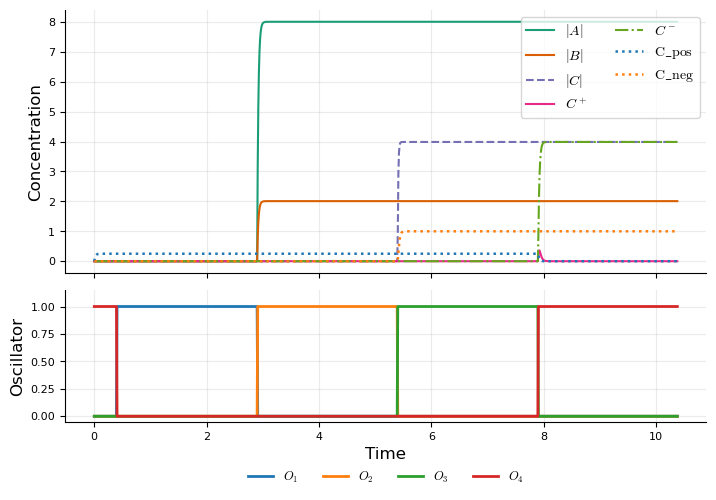

In [7]:
run_division_demo()